In [13]:
US_TWITTER_CSV_PATH  = r"data/result1/twitter.csv"
US_COUNTIES_SHP_PATH = r"data/result1/cb_2013_us_county_500k.shp"
CN_WEIBO_CSV_PATH    = r"data/result1/cities_minute_counts.csv"
POI_PATH = r'data/result1/POI_ALL.csv'
tc_path = r"data/result1/cities_24h_activity.csv"

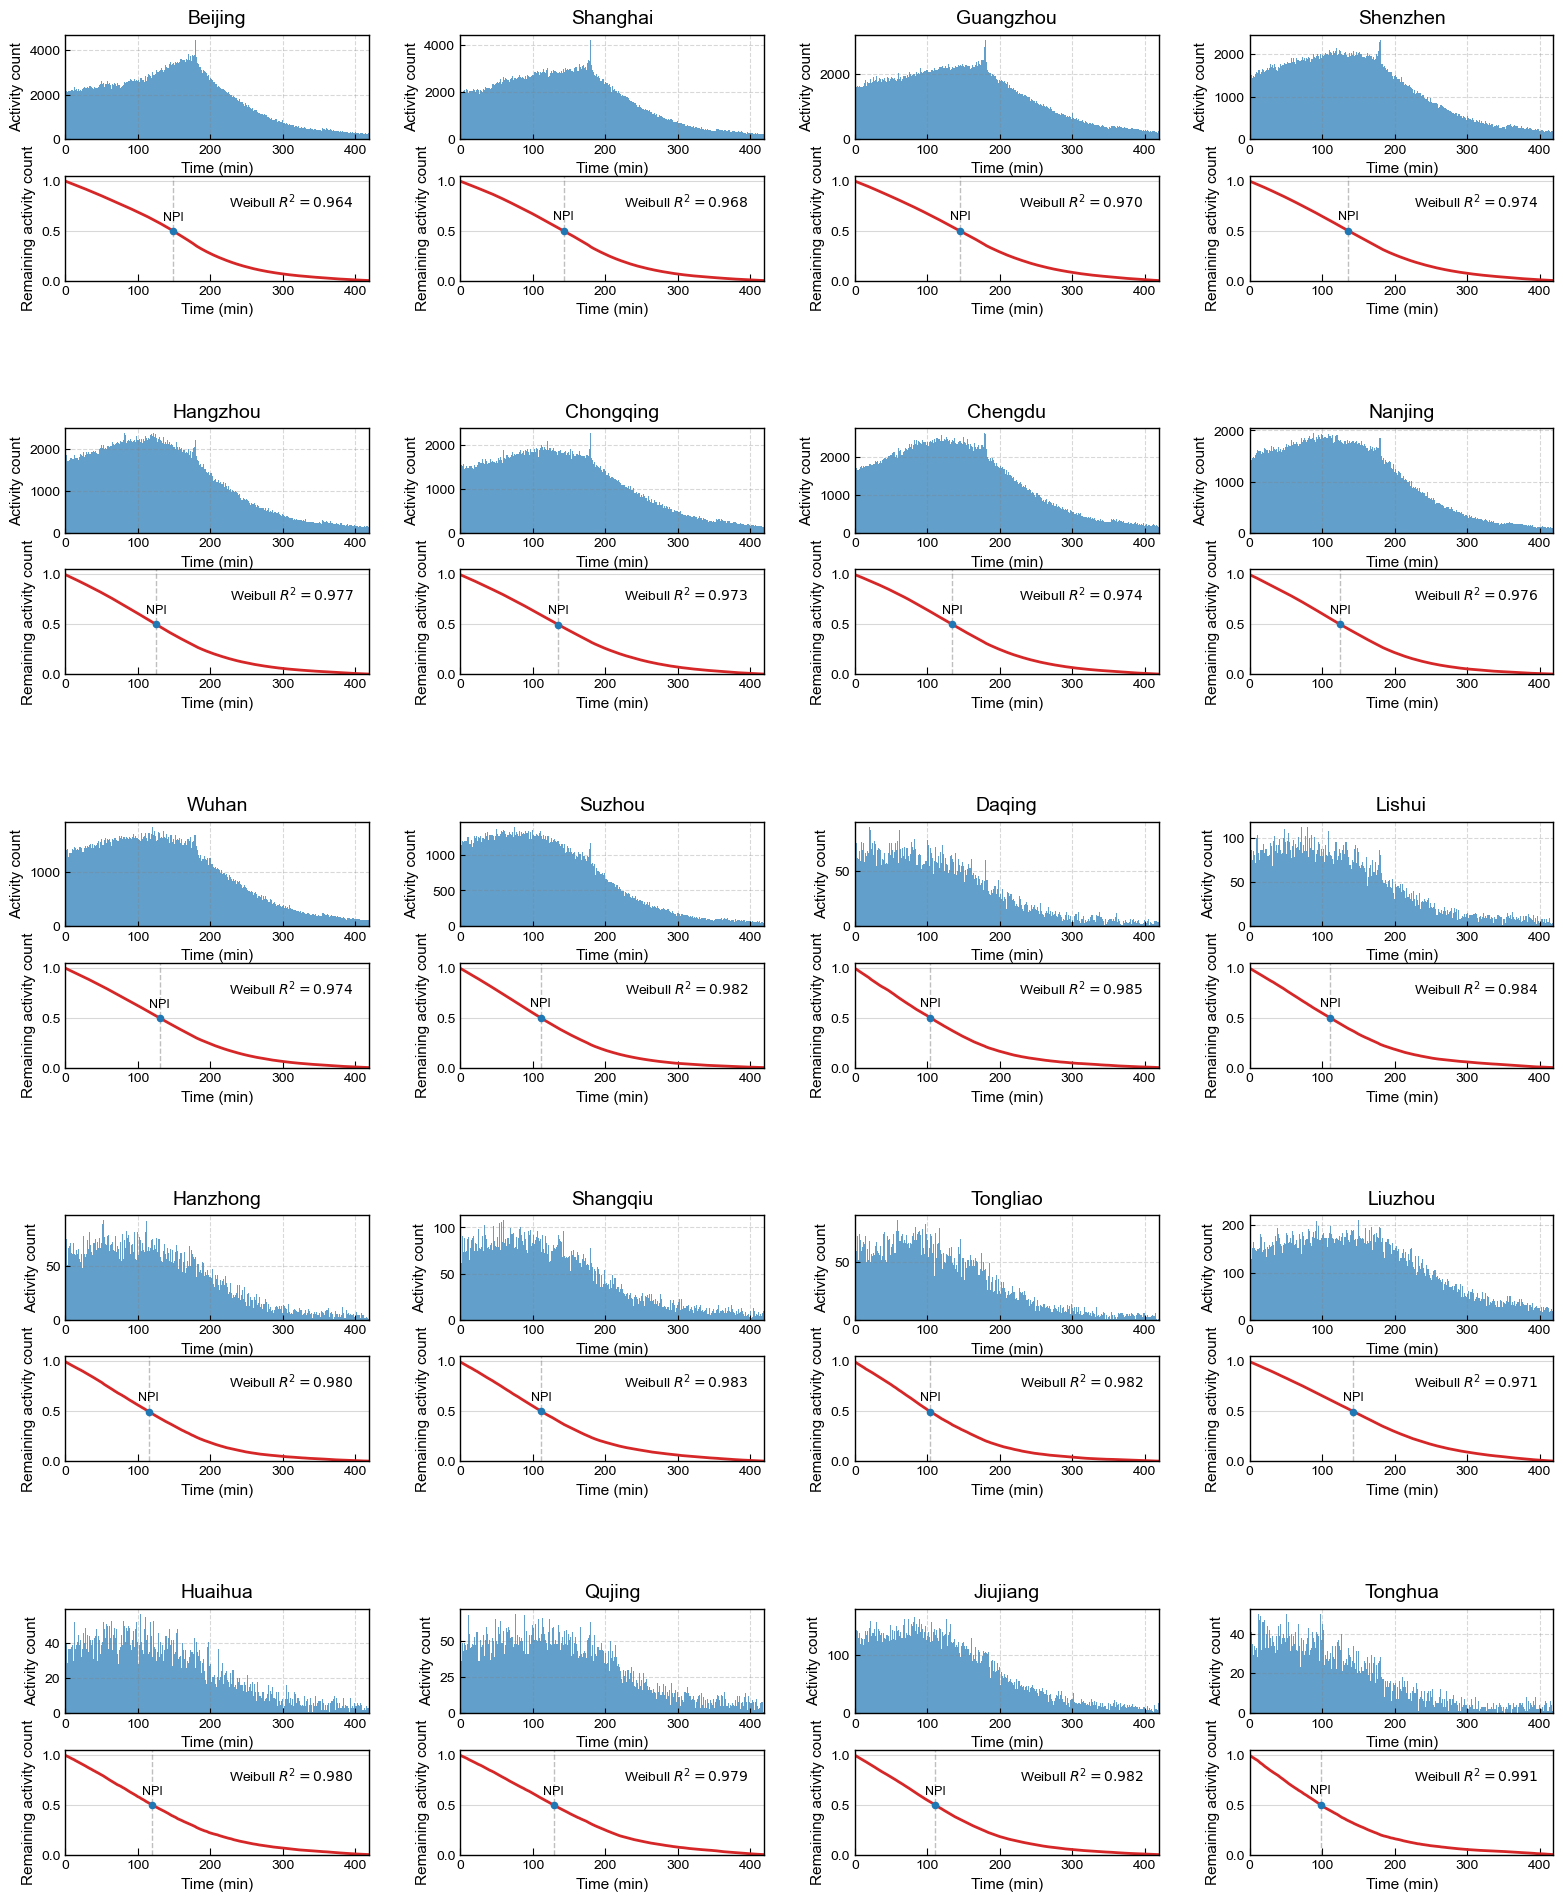

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import warnings
from pypinyin import pinyin, Style
from scipy.stats import linregress

warnings.filterwarnings("ignore")

fontsize = 12
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = fontsize
plt.rcParams['axes.titlesize'] = fontsize
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = fontsize
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

def get_pinyin(city_name):
    if not isinstance(city_name, str):
        return str(city_name)
    py_list = pinyin(city_name, style=Style.NORMAL)
    py_str = "".join([item[0] for item in py_list]).capitalize()
    return py_str

agg_df = pd.read_csv(CN_WEIBO_CSV_PATH)
agg_df['create_time'] = pd.to_datetime(agg_df['create_time'])

df_night_wb = agg_df[(agg_df['create_time'].dt.hour >= 21) | (agg_df['create_time'].dt.hour < 4)].copy()

df_night_wb['time_bin'] = df_night_wb['create_time'].apply(
    lambda dt: (dt.hour - 21) * 60 + dt.minute if dt.hour >= 21 else 180 + dt.hour * 60 + dt.minute
)

city_minute_counts = df_night_wb.groupby(['city', 'time_bin'])['post_count'].sum().reset_index()

city_totals = city_minute_counts.groupby('city')['post_count'].sum()
valid_cities = city_totals[city_totals >= 100].index.tolist()

if len(valid_cities) < 20:
    sample_size = len(valid_cities)
else:
    sample_size = 20

selected_cities = ['北京', '上海', '广州', '深圳', '杭州', '重庆', '成都', '南京', '武汉', '苏州',
                   '大庆', '丽水', '汉中', '商丘', '通辽', '柳州', '怀化', '曲靖', '九江', '通化' ]

cities_per_row = 4
num_city_rows = int(np.ceil(sample_size / cities_per_row))

fig = plt.figure(figsize=(16, 4.0 * num_city_rows))
outer_grid = gridspec.GridSpec(num_city_rows, cities_per_row, wspace=0.3, hspace=0.6)

for idx, city in enumerate(selected_cities):
    city_en = get_pinyin(city)
    
    city_row = idx // cities_per_row
    city_col = idx % cities_per_row
    
    inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[city_row, city_col], hspace=0.35)
    
    ax1 = fig.add_subplot(inner_grid[0])
    ax2 = fig.add_subplot(inner_grid[1])
    
    df_city = city_minute_counts[city_minute_counts['city'] == city]
    
    max_bin = df_city['time_bin'].max()
    ts = pd.Series(0, index=range(int(max_bin) + 1))
    ts.update(df_city.set_index('time_bin')['post_count'])
    
    ax1.bar(ts.index, ts.values, color='#1f77b4', width=1.0, alpha=0.7)
    
    ax1.set_title(f"{city_en}", fontsize=14, pad=8)
    ax1.set_xlabel("Time (min)")
    ax1.set_ylabel("Activity count")
    ax1.set_xlim(0, max_bin)
    ax1.grid(True, linestyle='--', color='gray', alpha=0.3)
    
    S = ts.cumsum().astype(float)
    S_total = S.iloc[-1]
    
    if S_total > 0:
        f = S / S_total
        one_minus_f = 1 - f
        
        t_vals = ts.index.values
        mask_wei = (one_minus_f > 1e-9) & (f > 1e-9) & (t_vals > 0)
        r2_w = np.nan
        if mask_wei.sum() > 3:
            x_wei = np.log(t_vals[mask_wei])
            y_wei = np.log(-np.log(one_minus_f.values[mask_wei]))
            _, _, r_val, _, _ = linregress(x_wei, y_wei)
            r2_w = r_val**2
        
        mask_50 = one_minus_f <= 0.5
        if mask_50.any():
            t_50 = mask_50.idxmax()
            if t_50 > 0:
                ax2.plot(ts.index, one_minus_f.values, color='#d62728', linewidth=2)
                
                # Highlight the NPI point
                y_val_at_t50 = one_minus_f[t_50]
                ax2.scatter([t_50], [y_val_at_t50], color='#1f77b4', s=20, zorder=5)
                ax2.axvline(x=t_50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
                ax2.text(t_50, y_val_at_t50 + 0.08, 'NPI', ha='center', va='bottom', fontsize=9, color='black')
                
                if not np.isnan(r2_w):
                    ax2.text(0.95, 0.85, f'Weibull $R^2 = {r2_w:.3f}$', transform=ax2.transAxes, 
                             ha='right', va='top', fontsize=10, color='black')
                
                ax2.set_xlabel("Time (min)")
                ax2.set_ylabel("Remaining activity count")
                ax2.set_xlim(0, max_bin)
                ax2.set_ylim(0, 1.05)
                ax2.set_yticks([0.0, 0.5, 1.0])
                
                ax2.tick_params(axis='y', length=0)
                ax2.tick_params(axis='x', length=5, direction='in')
                ax2.yaxis.grid(True, linestyle='-', color='gray', alpha=0.3)
            else:
                ax2.text(0.5, 0.5, 't_50 = 0', ha='center', va='center')
                ax2.set_axis_off()
        else:
             ax2.text(0.5, 0.5, 'No t_50', ha='center', va='center')
             ax2.set_axis_off()
    else:
        ax2.text(0.5, 0.5, 'Count = 0', ha='center', va='center')
        ax2.set_axis_off()

fig.subplots_adjust(left=0.05, right=0.98, top=0.96, bottom=0.05)
# fig.savefig('cities.jpg', dpi=300)
plt.show()

1. Loading Data and Spatial Join...
2. Processing Time and Extracting Night Data...
3. Selecting Top 20 Counties...
Total selected counties: 20
4. Plotting Activity and Weibull Decay...


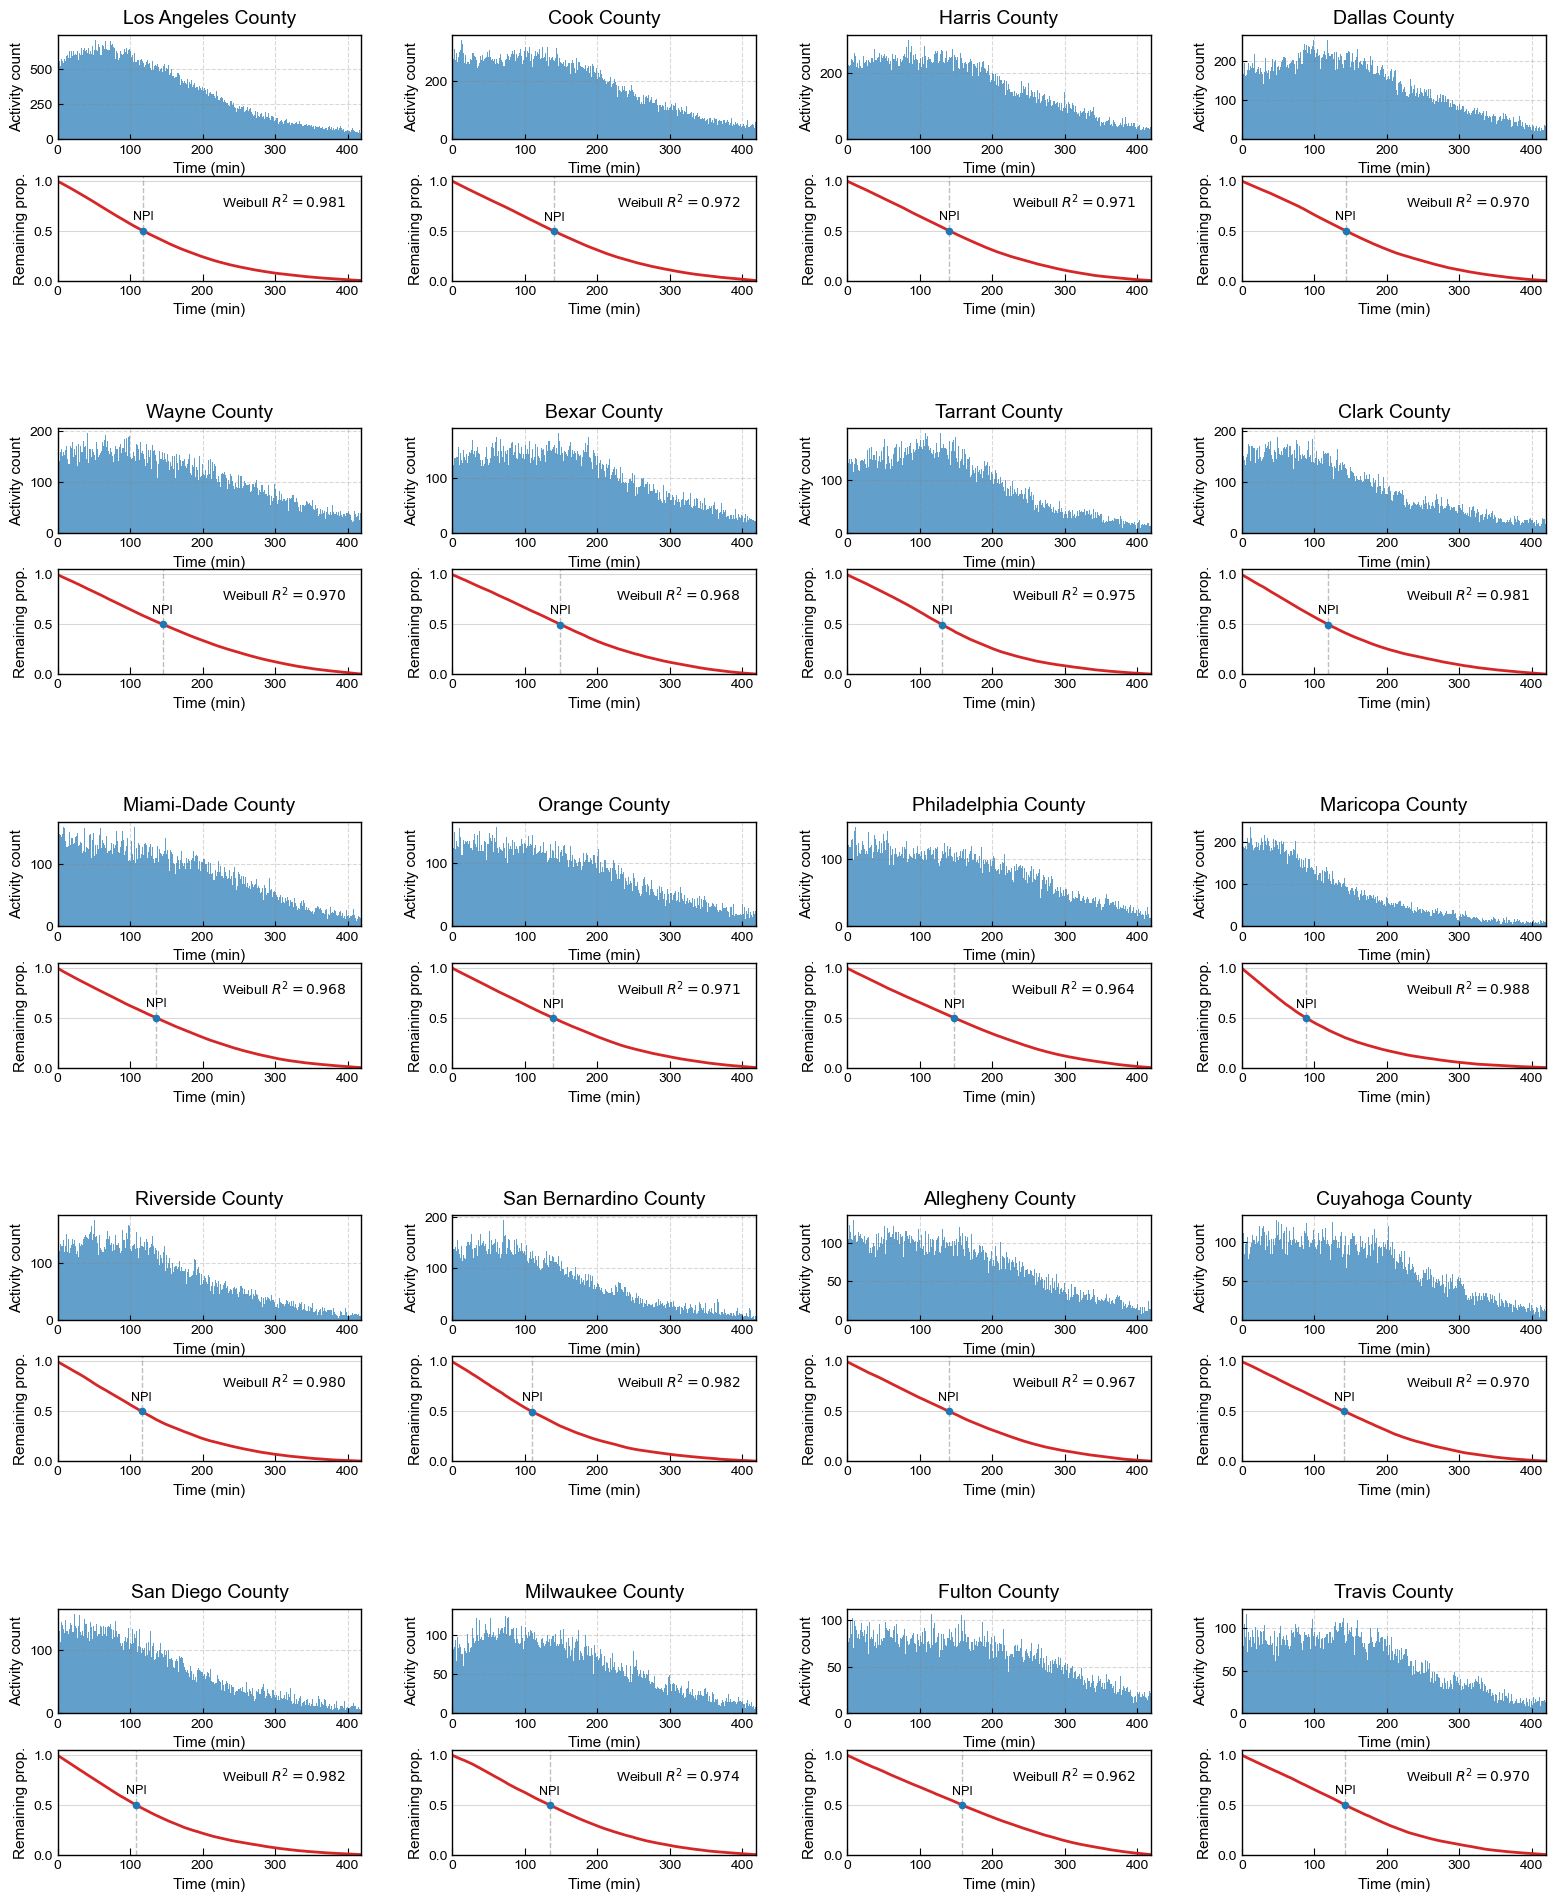

Done! Charts generated successfully.


In [15]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import warnings
from scipy.stats import linregress

warnings.filterwarnings("ignore")


# 绘图字体与格式设置
fontsize = 12
plt.rcParams['font.family'] = 'Arial' # 美国县名纯英文，使用 Arial 字体效果更好
plt.rcParams['font.size'] = fontsize
plt.rcParams['axes.titlesize'] = fontsize
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = fontsize
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

print("1. Loading Data and Spatial Join...")
df_us = pd.read_csv(US_TWITTER_CSV_PATH)
df_us = df_us.dropna(subset=['longitude', 'latitude'])

gdf_tweets = gpd.GeoDataFrame(
    df_us, 
    geometry=gpd.points_from_xy(df_us['longitude'], df_us['latitude']), 
    crs="EPSG:4326"
)
gdf_counties = gpd.read_file(US_COUNTIES_SHP_PATH).to_crs("EPSG:4326")

# 空间连接以获取每个推文所在的县
joined_us = gpd.sjoin(gdf_tweets, gdf_counties, how="inner", predicate="within")

print("2. Processing Time and Extracting Night Data...")
joined_us['timestamp_dt'] = pd.to_datetime(joined_us['timestamp'].astype(str), format='%Y%m%d%H%M%S')
offset_dict = {1: 1, 2: 0, 3: -1, 4: -2}
joined_us['local_time_dt'] = joined_us['timestamp_dt'] + pd.to_timedelta(joined_us['timezone'].map(offset_dict).fillna(0), unit='h')

# 筛选 21:00 到 03:59 的夜间数据
df_night_us = joined_us[(joined_us['local_time_dt'].dt.hour >= 21) | (joined_us['local_time_dt'].dt.hour < 4)].copy()

df_night_us['time_bin'] = df_night_us['local_time_dt'].apply(
    lambda dt: (dt.hour - 21) * 60 + dt.minute if dt.hour >= 21 else 180 + dt.hour * 60 + dt.minute
)

print("3. Selecting Top 20 Counties...")
# 计算每个县(使用唯一索引)的夜间推文总数
county_totals = df_night_us.groupby('index_right').size()

# 筛选总数超过100条的有效县
valid_indices = county_totals[county_totals >= 100].index.tolist()

# 获取 Top 20
selected_indices = county_totals.loc[valid_indices].nlargest(20).index.tolist()
sample_size = len(selected_indices)

print(f"Total selected counties: {sample_size}")

print("4. Plotting Activity and Weibull Decay...")
cities_per_row = 4
num_city_rows = int(np.ceil(sample_size / cities_per_row))

fig = plt.figure(figsize=(16, 4.0 * num_city_rows))
outer_grid = gridspec.GridSpec(num_city_rows, cities_per_row, wspace=0.3, hspace=0.6)

# 固定最大的 time_bin，让所有图表的 X 轴保持一致 (21:00 ~ 03:59 = 420 分钟, index 0-419)
max_bin = 419 

for idx_pos, county_idx in enumerate(selected_indices):
    county_name = gdf_counties.loc[county_idx, 'NAME']
    
    # 统一使用 Top N 标签，让图表更易读
    display_title = f"{county_name} County"
    
    city_row = idx_pos // cities_per_row
    city_col = idx_pos % cities_per_row
    
    inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[city_row, city_col], hspace=0.35)
    
    ax1 = fig.add_subplot(inner_grid[0])
    ax2 = fig.add_subplot(inner_grid[1])
    
    # 获取该县的数据
    df_county = df_night_us[df_night_us['index_right'] == county_idx]
    
    # 统计每分钟的数量，并重建完整的 420 分钟索引填补 0
    ts_counts = df_county['time_bin'].value_counts()
    ts = pd.Series(0, index=range(max_bin + 1))
    ts.update(ts_counts)
    
    # 上半部分：柱状图 (Activity count)
    ax1.bar(ts.index, ts.values, color='#1f77b4', width=1.0, alpha=0.7)
    
    ax1.set_title(display_title, fontsize=14, pad=8)
    ax1.set_xlabel("Time (min)")
    ax1.set_ylabel("Activity count")
    ax1.set_xlim(0, max_bin)
    ax1.grid(True, linestyle='--', color='gray', alpha=0.3)
    
    # 下半部分：衰减曲线和 Weibull 计算
    S = ts.cumsum().astype(float)
    S_total = S.iloc[-1]
    
    if S_total > 0:
        f = S / S_total
        one_minus_f = 1 - f
        
        t_vals = ts.index.values
        mask_wei = (one_minus_f > 1e-9) & (f > 1e-9) & (t_vals > 0)
        r2_w = np.nan
        
        if mask_wei.sum() > 3:
            x_wei = np.log(t_vals[mask_wei])
            y_wei = np.log(-np.log(one_minus_f.values[mask_wei]))
            _, _, r_val, _, _ = linregress(x_wei, y_wei)
            r2_w = r_val**2
        
        mask_50 = one_minus_f <= 0.5
        if mask_50.any():
            t_50 = mask_50.idxmax()
            if t_50 > 0:
                ax2.plot(ts.index, one_minus_f.values, color='#d62728', linewidth=2)
                
                # Highlight the NPI point
                y_val_at_t50 = one_minus_f[t_50]
                ax2.scatter([t_50], [y_val_at_t50], color='#1f77b4', s=20, zorder=5)
                ax2.axvline(x=t_50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
                ax2.text(t_50, y_val_at_t50 + 0.08, 'NPI', ha='center', va='bottom', fontsize=9, color='black')
                
                if not np.isnan(r2_w):
                    ax2.text(0.95, 0.85, f'Weibull $R^2 = {r2_w:.3f}$', transform=ax2.transAxes, 
                             ha='right', va='top', fontsize=10, color='black')
                
                ax2.set_xlabel("Time (min)")
                ax2.set_ylabel("Remaining prop.")
                ax2.set_xlim(0, max_bin)
                ax2.set_ylim(0, 1.05)
                ax2.set_yticks([0.0, 0.5, 1.0])
                
                ax2.tick_params(axis='y', length=0)
                ax2.tick_params(axis='x', length=5, direction='in')
                ax2.yaxis.grid(True, linestyle='-', color='gray', alpha=0.3)
            else:
                ax2.text(0.5, 0.5, 't_50 = 0', ha='center', va='center')
                ax2.set_axis_off()
        else:
             ax2.text(0.5, 0.5, 'No t_50', ha='center', va='center')
             ax2.set_axis_off()
    else:
        ax2.text(0.5, 0.5, 'Count = 0', ha='center', va='center')
        ax2.set_axis_off()

fig.subplots_adjust(left=0.05, right=0.98, top=0.96, bottom=0.05)
plt.savefig('us_county_activity_weibull.jpg', dpi=300, bbox_inches='tight')
plt.show()

print("Done! Charts generated successfully.")

Processing US Twitter Data (7 days)...
Processing China Weibo Data (1 year baseline)...
Analyzing US Data...
Bootstrapping Weibo Data (Sampling 5 sets of continuous 7-days)...
Generating Plot 1: Decay Curves...


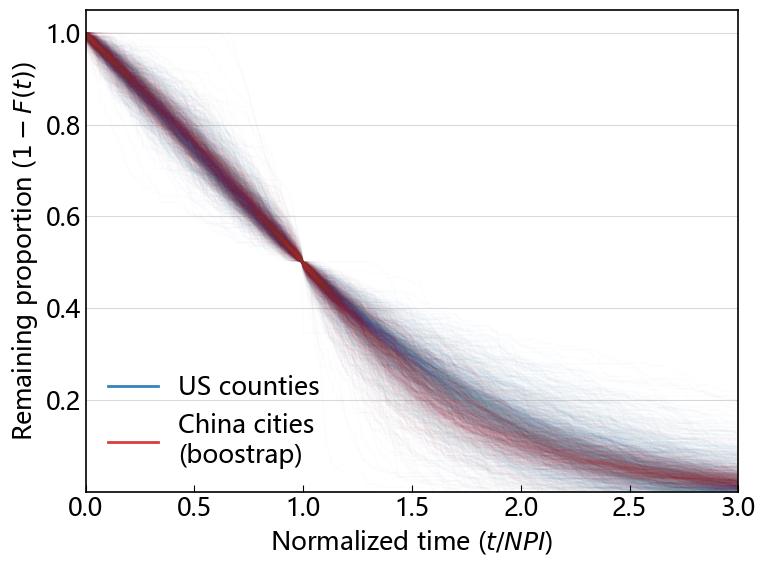

Generating Plot 2: Weibull R2 Violin Plot...


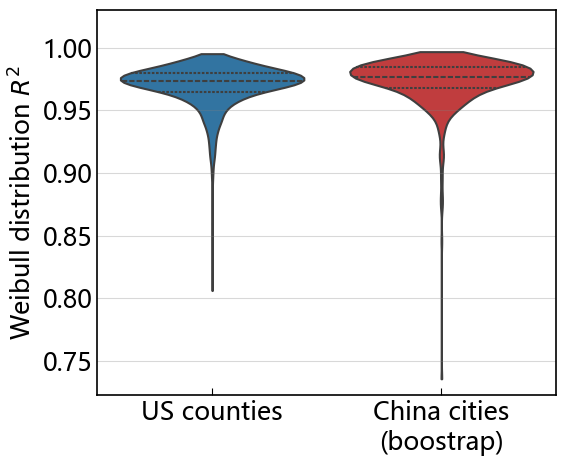

US counties Median R2: 0.9731
China Bootstrapped Median R2: 0.9769


In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from scipy.stats import linregress
import random
import warnings

warnings.filterwarnings("ignore")




fontsize = 18
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['font.size'] = fontsize
plt.rcParams['axes.titlesize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['legend.fontsize'] = fontsize
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

print("Processing US Twitter Data (7 days)...")
df_us = pd.read_csv(US_TWITTER_CSV_PATH)
gdf_tweets = gpd.GeoDataFrame(df_us, geometry=gpd.points_from_xy(df_us['longitude'], df_us['latitude']), crs="EPSG:4326")
gdf_cities = gpd.read_file(US_COUNTIES_SHP_PATH).to_crs("EPSG:4326")

joined_us = gpd.sjoin(gdf_tweets, gdf_cities, how="inner", predicate="within")
df_us = joined_us.rename(columns={'NAME': 'county_name'})

df_us['timestamp_dt'] = pd.to_datetime(df_us['timestamp'].astype(str), format='%Y%m%d%H%M%S')
offset_dict = {1: 1, 2: 0, 3: -1, 4: -2}
df_us['local_time_dt'] = df_us['timestamp_dt'] + pd.to_timedelta(df_us['timezone'].map(offset_dict).fillna(0), unit='h')

df_night_us = df_us[(df_us['local_time_dt'].dt.hour >= 21) | (df_us['local_time_dt'].dt.hour < 4)].copy()
df_night_us['time_bin'] = df_night_us['local_time_dt'].apply(
    lambda dt: (dt.hour - 21) * 60 + dt.minute if dt.hour >= 21 else 180 + dt.hour * 60 + dt.minute
)

print("Processing China Weibo Data (1 year baseline)...")
agg_df = pd.read_csv(CN_WEIBO_CSV_PATH)
agg_df['create_time'] = pd.to_datetime(agg_df['create_time'])

df_wb = agg_df.loc[agg_df.index.repeat(agg_df['post_count'])].reset_index(drop=True)
df_wb = df_wb.drop(columns=['post_count'])

df_night_wb = df_wb[(df_wb['create_time'].dt.hour >= 21) | (df_wb['create_time'].dt.hour < 4)].copy()
df_night_wb['time_bin'] = df_night_wb['create_time'].apply(
    lambda dt: (dt.hour - 21) * 60 + dt.minute if dt.hour >= 21 else 180 + dt.hour * 60 + dt.minute
)
df_night_wb['date_only'] = df_night_wb['create_time'].dt.date

def analyze_city_decay(group):
    ts = group['time_bin'].value_counts()
    if ts.sum() < 100: 
        return None
        
    ts_sorted = ts.sort_index().reindex(range(0, int(ts.index.max()) + 1), fill_value=0)
    S = ts_sorted.cumsum().astype(float)
    S_total = S.iloc[-1]
    if S_total == 0: return None
    
    f = S / S_total
    one_minus_f = 1 - f
    
    mask_50 = one_minus_f <= 0.5
    if not mask_50.any(): return None
    t_50 = mask_50.idxmax()
    if t_50 <= 0: return None
    
    norm_time = ts_sorted.index / t_50
    
    t_vals = ts_sorted.index.values
    mask_wei = (one_minus_f > 1e-9) & (f > 1e-9) & (t_vals > 0)
    r2_w = np.nan
    
    if mask_wei.sum() > 3:
        x_wei = np.log(t_vals[mask_wei])
        y_wei = np.log(-np.log(one_minus_f.values[mask_wei]))
        _, _, r_val, _, _ = linregress(x_wei, y_wei)
        r2_w = r_val**2
        
    return pd.Series({
        'norm_time': norm_time,
        'one_minus_f': one_minus_f.values,
        'weibull_r2': r2_w
    })

print("Analyzing US Data...")
us_results = df_night_us.groupby('county_name').apply(analyze_city_decay).dropna()

print("Bootstrapping Weibo Data (Sampling 5 sets of continuous 7-days)...")
unique_dates = pd.Series(df_night_wb['date_only'].unique()).sort_values().reset_index(drop=True)

NUM_SAMPLES = 5 
random.seed(42)  

valid_start_indices = range(len(unique_dates) - 6)
sampled_indices = random.sample(valid_start_indices, NUM_SAMPLES)

cn_sampled_results_list = []

for i, start_idx in enumerate(sampled_indices):
    start_date = unique_dates[start_idx]
    end_date = unique_dates[start_idx + 6]
    
    mask = (df_night_wb['date_only'] == start_date) | (df_night_wb['date_only'] == end_date)
    df_sample = df_night_wb[mask]
    
    res = df_sample.groupby('city').apply(analyze_city_decay).dropna()

    if not res.empty:
        res['sample_id'] = f"Sample_{i+1}_{start_date}"
        cn_sampled_results_list.append(res)

cn_results = pd.concat(cn_sampled_results_list)

print("Generating Plot 1: Decay Curves...")
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in us_results.iterrows():
    ax.plot(row['norm_time'], row['one_minus_f'], color='#1f77b4', alpha=0.015, linewidth=1, zorder=1)
    
for _, row in cn_results.iterrows():
    ax.plot(row['norm_time'], row['one_minus_f'], color='#d62728', alpha=0.015, linewidth=1, zorder=2)

ax.set_xlim(0, 3)
ax.set_ylim(0, 1.05)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0]) 

ax.set_xlabel("Normalized time ($t / NPI$)")
ax.set_ylabel("Remaining proportion ($1 - F(t)$)")

ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', length=5, direction='in')

us_line = mlines.Line2D([], [], color='#1f77b4', alpha=0.9, linewidth=2, label='US counties')
cn_line = mlines.Line2D([], [], color='#d62728', alpha=0.9, linewidth=2, label='China cities\n(boostrap)')
ax.legend(handles=[us_line, cn_line], loc='lower left', frameon=False)

ax.yaxis.grid(True, linestyle='-', color='gray', alpha=0.3)
ax.xaxis.grid(False) 

plt.tight_layout()
# plt.savefig(r"decay_curves_normalized.jpg", format='jpg', bbox_inches='tight', dpi=300)
plt.show()

print("Generating Plot 2: Weibull R2 Violin Plot...")
fig2, ax2 = plt.subplots(figsize=(6, 5))

r2_df = pd.DataFrame({
    'R2': pd.concat([us_results['weibull_r2'], cn_results['weibull_r2']]),
    'Region Type': ['US counties'] * len(us_results) + ['China cities\n(boostrap)'] * len(cn_results)
}).dropna()

sns.violinplot(
    x='Region Type', y='R2', data=r2_df, 
    palette=['#1f77b4', '#d62728'], 
    inner='quartile', linewidth=1.5, ax=ax2, cut=0
)

ax2.set_ylim(None, 1.03)
ax2.set_xlabel("")
ax2.set_ylabel("Weibull distribution $R^2$")

ax2.tick_params(axis='y', length=0)
ax2.tick_params(axis='x', length=5, direction='in')
ax2.yaxis.grid(True, linestyle='-', color='gray', alpha=0.3)
ax2.xaxis.grid(False)

plt.tight_layout()
# plt.savefig(r"weibull_r2_violin.jpg", format='jpg', bbox_inches='tight', dpi=300)
plt.show()

us_median_r2 = us_results['weibull_r2'].median()
cn_median_r2 = cn_results['weibull_r2'].median()

print(f"US counties Median R2: {us_median_r2:.4f}")
print(f"China Bootstrapped Median R2: {cn_median_r2:.4f}")

wb_full_results = df_night_wb.groupby('city').apply(analyze_city_decay).dropna()


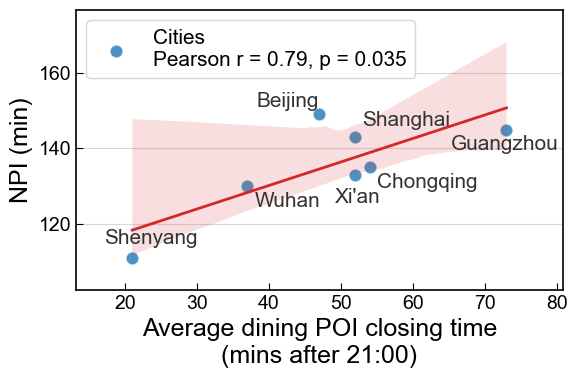

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import os

def calculate_npi(group):
    ts = group['time_bin'].value_counts()
    if ts.sum() < 100: 
        return np.nan
    
    ts_sorted = ts.sort_index().reindex(range(0, int(ts.index.max()) + 1), fill_value=0)
    S = ts_sorted.cumsum().astype(float)
    S_total = S.iloc[-1]
    
    if S_total == 0: 
        return np.nan
        
    one_minus_f = 1 - (S / S_total)
    mask_50 = one_minus_f <= 0.5
    
    if not mask_50.any(): 
        return np.nan
        
    return mask_50.idxmax()

def time_to_minutes(t_str):
    if pd.isna(t_str): 
        return np.nan
    h, m = map(int, str(t_str).split(':'))
    if h < 12: 
        h += 24
    return (h - 21) * 60 + m

def process_and_plot(category_name, filename, ax, npi_data):
    try:
        poi_df = pd.read_csv(filename)
    except Exception:
        return
        
    city_col = '城市' if '城市' in poi_df.columns else 'city'
    time_col = '平均打烊时间' if '平均打烊时间' in poi_df.columns else 'closing_time'
    
    poi_df['match_name'] = poi_df[city_col].str[:2]
    poi_df['city_en'] = poi_df['match_name'].map(city_translation)
    poi_df['poi_closing_time_min'] = poi_df[time_col].apply(time_to_minutes)
    
    merged_df = pd.merge(poi_df, npi_data, on='match_name', how='inner')
    
    x = merged_df['poi_closing_time_min']
    y = merged_df['NPI']
    
    corr, p_value = pearsonr(x, y)
    
    p_label = f"p = {p_value:.3f}" if p_value >= 0.001 else "p < 0.001"
    stats_label = f"Cities\nPearson r = {corr:.2f}, {p_label}"
    
    sns.regplot(
        x=x, y=y, ax=ax,
        ci=95,
        scatter_kws={'s': 90, 'color': '#1f77b4', 'edgecolors': 'white', 'alpha': 0.8},
        line_kws={'color': '#d62728', 'linewidth': 2},
        label=stats_label
    )
    
    ax.legend(loc='upper left', frameon=True, shadow=False)
    
    for i, row in merged_df.iterrows():
        city_en = row['city_en']
        offset = label_offsets.get(city_en, (5, 5))
        
        ax.annotate(
            city_en, 
            (row['poi_closing_time_min'], row['NPI']),
            xytext=offset, 
            textcoords='offset points',
            fontsize=15,
            color='#333333'
        )
        
    ax.margins(x=0.15, y=0.15)
    ax.set_xlabel(f"Average {category_name} POI closing time\n(mins after 21:00)", fontsize=18)
    ax.set_ylabel("NPI (min)", fontsize=18)
    ax.yaxis.grid(True, linestyle='-', color='gray', alpha=0.3)
    ax.xaxis.grid(False)
    ax.tick_params(direction='in', length=5)

npi_df = df_night_wb.groupby('city').apply(calculate_npi).reset_index(name='NPI')
npi_df['match_name'] = npi_df['city'].str[:2]

poi_files = {
    'dining': r'data/result1/POI_dining.csv',
    'shopping': r'data/result1/POI_shopping.csv',
    'entertainment': r'data/result1/POI_ent.csv',
    'all': r'data/result1/POI_ALL.csv'
}

city_translation = {
    '北京': 'Beijing',
    '上海': 'Shanghai',
    '沈阳': 'Shenyang',
    '武汉': 'Wuhan',
    '广州': 'Guangzhou',
    '西安': "Xi'an",
    '重庆': 'Chongqing'
}

fontsize = 14
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = fontsize
plt.rcParams['axes.titlesize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

label_offsets = {
    'Beijing': (-45, 5),
    'Shanghai': (5, 8),
    'Shenyang': (-20, 10),
    'Wuhan': (5, -15),
    'Guangzhou': (-40, -15),
    "Xi'an": (-15, -20),
    'Chongqing': (5, -15)
}

fig_food, ax_food = plt.subplots(figsize=(6, 4))
process_and_plot('dining', poi_files['dining'], ax_food, npi_df)
plt.tight_layout()
fig_food.savefig('dining_poi.jpg', dpi=300, bbox_inches='tight')
plt.show()

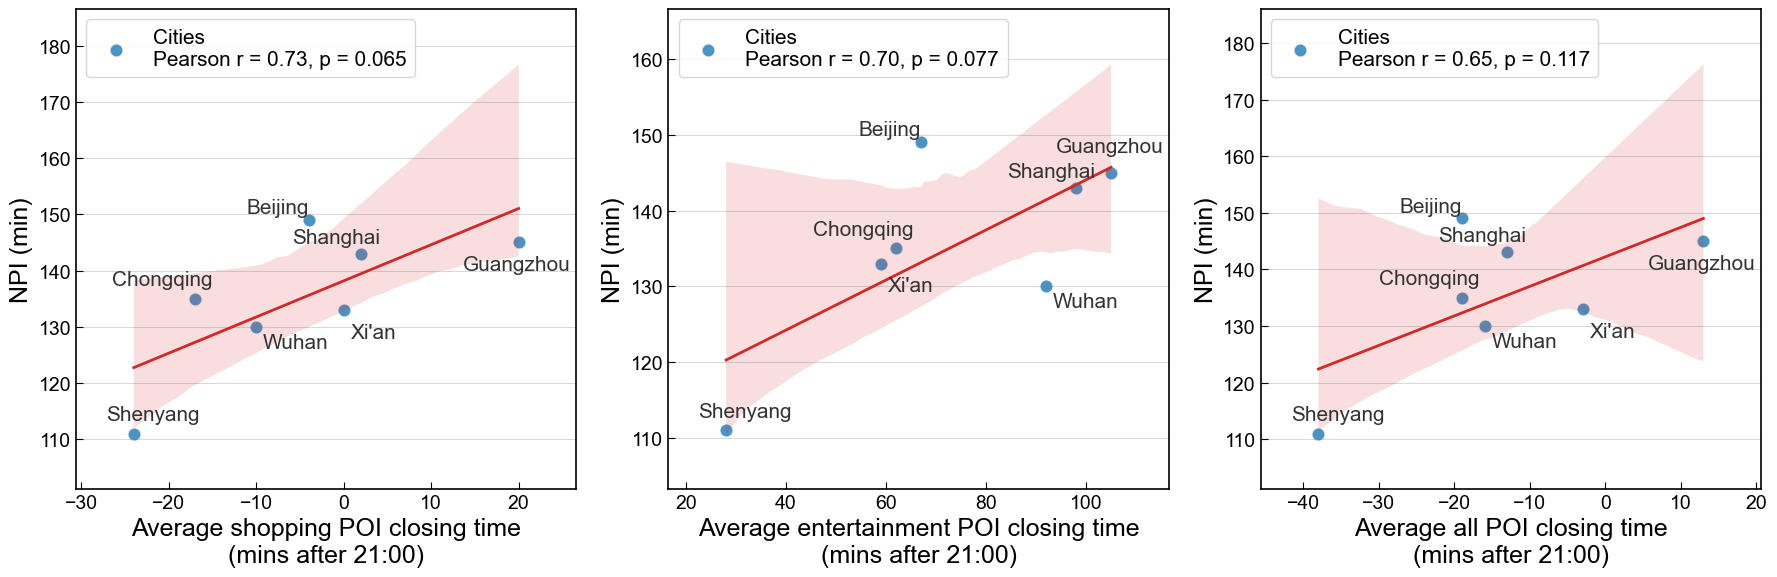

In [100]:
fig_others, axes_others = plt.subplots(1, 3, figsize=(18, 6))
other_categories = ['shopping', 'entertainment', 'all']
label_offsets = {
    'Beijing': (-45, 5),
    'Shanghai': (-50, 8),
    'Shenyang': (-20, 10),
    'Wuhan': (5, -15),
    'Guangzhou': (-40, -20),
    "Xi'an": (5, -20),
    'Chongqing': (-60, 10)
}
original_guangzhou_offset = (-40, -20) 

for ax, cat in zip(axes_others, other_categories):

    if cat == 'entertainment':
        label_offsets['Guangzhou'] = (-40, 15)
    else:
        label_offsets['Guangzhou'] = original_guangzhou_offset
        
    process_and_plot(cat, poi_files[cat], ax, npi_df)

plt.tight_layout()
fig_others.savefig('other_pois.jpg', dpi=300, bbox_inches='tight')
plt.show()

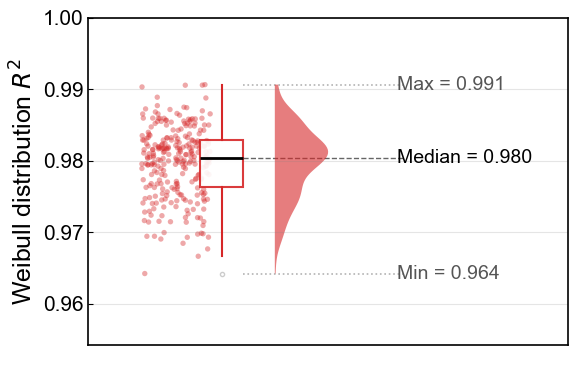

Total cities analyzed: 276
Whole Year Median R2: 0.9804
Min R2: 0.9642, Max R2: 0.9906


In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


r2_data = wb_full_results['weibull_r2'].dropna().values

color = '#d62728'


fig, ax = plt.subplots(figsize=(6, 4))

v = ax.violinplot(r2_data, positions=[0.1], widths=0.2, showmeans=False, showextrema=False)
for b in v['bodies']:
    b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], 0.1, np.inf)
    b.set_facecolor(color)
    b.set_alpha(0.6)
    b.set_edgecolor('none')
    

np.random.seed(42)
jitter = np.random.uniform(-0.15, -0.02, size=len(r2_data))
ax.scatter(np.zeros(len(r2_data)) + jitter, r2_data, 
           color=color, s=15, alpha=0.4, zorder=1, edgecolors='none')
    

ax.boxplot(r2_data, positions=[0], widths=0.08, showcaps=False, patch_artist=True,
           boxprops=dict(facecolor='white', color=color, linewidth=1.5, alpha=0.9),
           medianprops=dict(color='black', linewidth=2),
           whiskerprops=dict(color=color, linewidth=1.5),
           flierprops=dict(marker='o', color=color, markersize=3, alpha=0.2), zorder=2)


med_val = np.median(r2_data)
max_val = np.max(r2_data)
min_val = np.min(r2_data)

ax.hlines(med_val, xmin=0.04, xmax=0.34, color='black', linestyle='--', linewidth=1, alpha=0.6, zorder=0)
ax.hlines(max_val, xmin=0.04, xmax=0.34, color='gray', linestyle=':', linewidth=1.2, alpha=0.6, zorder=0)
ax.hlines(min_val, xmin=0.04, xmax=0.34, color='gray', linestyle=':', linewidth=1.2, alpha=0.6, zorder=0)

ax.text(0.33, med_val, f'Median = {med_val:.3f}', va='center', ha='left', fontsize=14, color='black')
ax.text(0.33, max_val, f'Max = {max_val:.3f}', va='center', ha='left', fontsize=14, color='#555555')
ax.text(0.33, min_val, f'Min = {min_val:.3f}', va='center', ha='left', fontsize=14, color='#555555')

ax.set_xticks([0])
ax.set_xticklabels([' '], fontsize=14)
ax.set_ylabel("Weibull distribution $R^2$", fontsize=18)


y_min = np.min(r2_data)
ax.set_ylim(y_min - 0.01 if y_min > 0.7 else 0.7, 1.0) 

ax.set_xlim(-0.25, 0.65)


ax.yaxis.grid(True, linestyle='-', color='gray', alpha=0.2)
ax.xaxis.grid(False)


ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True) 

ax.tick_params(axis='x', length=0) 
ax.tick_params(axis='y', labelsize=15)

plt.tight_layout()
plt.savefig(r"weibull_r2_wholeyear.jpg", format='jpg', bbox_inches='tight', dpi=300)
plt.show()

print(f"Total cities analyzed: {len(r2_data)}")
print(f"Whole Year Median R2: {np.median(r2_data):.4f}")
print(f"Min R2: {np.min(r2_data):.4f}, Max R2: {np.max(r2_data):.4f}")

Target cities identified: ['南宁', '南昌', '广州', '成都', '深圳', '重庆']
Generating Correlation Plot...


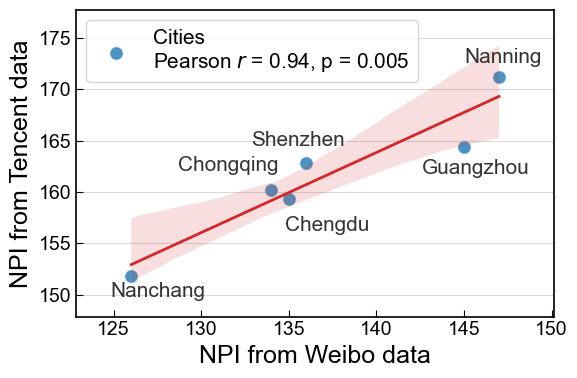

,City,City_EN,Tencent_Median,Weibo_Median
0,南宁,Nanning,171.20,147
1,南昌,Nanchang,151.84,126
2,广州,Guangzhou,164.41,145
3,成都,Chengdu,160.21,134
4,深圳,Shenzhen,162.87,136
5,重庆,Chongqing,159.30,135


In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr




df_tc = pd.read_csv(tc_path)


target_cities = [col for col in df_tc.columns if col != 'hour']
print(f"Target cities identified: {target_cities}")


night_hours = [21, 22, 23, 0, 1, 2, 3]
hour_mapping = {21: 0, 22: 1, 23: 2, 0: 3, 1: 4, 2: 5, 3: 6}

df_tc_night = df_tc[df_tc['hour'].isin(night_hours)].copy()
df_tc_night['hour_seq'] = df_tc_night['hour'].map(hour_mapping)
df_tc_night = df_tc_night.sort_values('hour_seq').reset_index(drop=True)


tc_medians_mins = {}
for city in target_cities:
    counts = df_tc_night[city].values
    total_count = counts.sum()
    cumsum = np.cumsum(counts)

    target_val = total_count / 2.0
    median_idx = np.searchsorted(cumsum, target_val)
    

    if median_idx == 0:
        frac = target_val / cumsum[0]
        exact_hour_offset = frac
    else:
        prev_sum = cumsum[median_idx-1]
        curr_val = counts[median_idx]
        frac = (target_val - prev_sum) / curr_val
        exact_hour_offset = median_idx + frac

    tc_medians_mins[city] = exact_hour_offset * 60



wb_medians_mins = {}

for city in target_cities:

    city_mask = df_night_wb['city'].str.contains(city, na=False)
    city_data = df_night_wb[city_mask]
    
    if not city_data.empty:

        ts = city_data['time_bin'].value_counts()
        

        if not ts.empty:
            ts_sorted = ts.sort_index().reindex(range(0, int(ts.index.max()) + 1), fill_value=0)
            S = ts_sorted.cumsum().astype(float)
            S_total = S.iloc[-1]
            
            f = S / S_total
            one_minus_f = 1 - f

            mask_50 = one_minus_f <= 0.5
            
            if mask_50.any():
                t_50 = mask_50.idxmax()
                wb_medians_mins[city] = t_50
            else:
                print(f"Warning: Could not find 50% decay point for City '{city}'.")
                wb_medians_mins[city] = np.nan
        else:
            wb_medians_mins[city] = np.nan
    else:
        print(f"Warning: City '{city}' not found in Weibo dataset.")
        wb_medians_mins[city] = np.nan


city_name_mapping = {
    '南宁': 'Nanning',
    '广州': 'Guangzhou',
    '成都': 'Chengdu',
    '重庆': 'Chongqing',
    '深圳': 'Shenzhen',
    '南昌': 'Nanchang'
}

df_compare = pd.DataFrame({
    'City': target_cities,
    'City_EN': [city_name_mapping.get(c, c) for c in target_cities],
    'Tencent_Median': [tc_medians_mins.get(c, np.nan) for c in target_cities],
    'Weibo_Median': [wb_medians_mins.get(c, np.nan) for c in target_cities]
}).dropna()


r_val, p_val = pearsonr(df_compare['Tencent_Median'], df_compare['Weibo_Median'])


p_label = f"p = {p_val:.3f}" if p_val >= 0.001 else "p < 0.001"
stats_label = f"Cities\nPearson $r$ = {r_val:.2f}, {p_label}"


print("Generating Correlation Plot...")
fig, ax = plt.subplots(figsize=(6, 4))

sns.regplot(
    data=df_compare, 
    x='Weibo_Median', 
    y='Tencent_Median',
    ci=95, 
    scatter_kws={'s': 100, 'color': '#1f77b4', 'edgecolor': 'white', 'alpha': 0.8},
    line_kws={'color': '#d62728', 'linewidth': 2},
    label=stats_label,
    ax=ax
)


ax.legend(loc='upper left', fontsize=15, frameon=True, shadow=False)


label_offsets = {
    'Nanchang': (-15, -15),  
    'Chengdu': (10, -30),    
    'Chongqing': (-80, 20), 
    'Shenzhen': (-40, 12),  
    'Guangzhou': (-30, -20),  
    'Nanning': (-25, 10), 
}

for i, row in df_compare.iterrows():
    city_en = row['City_EN']
    offset = label_offsets.get(city_en, (5, 5))
    
    ax.annotate(
        city_en, 
        (row['Weibo_Median'], row['Tencent_Median']),
        xytext=offset, 
        textcoords='offset points',
        fontsize=15,
        color='#333333'
    )


ax.margins(x=0.15, y=0.15)


ax.set_xlabel("NPI from Weibo data", fontsize=18)
ax.set_ylabel("NPI from Tencent data", fontsize=18)

ax.yaxis.grid(True, linestyle='-', color='gray', alpha=0.3)
ax.xaxis.grid(False) 

ax.tick_params(direction='in', length=5)

plt.tight_layout()
plt.savefig("tencent_weibo_correlation.jpg", format='jpg', bbox_inches='tight', dpi=300)
plt.show()

display(df_compare.round(2))

Fitting theoretical distributions and calculating R2...
Exponential R²: 0.9542
Weibull R²: 0.9983
Lognormal R²: 0.9858
Gen-Exponential R²: 0.9946
Gamma R²: 0.9958


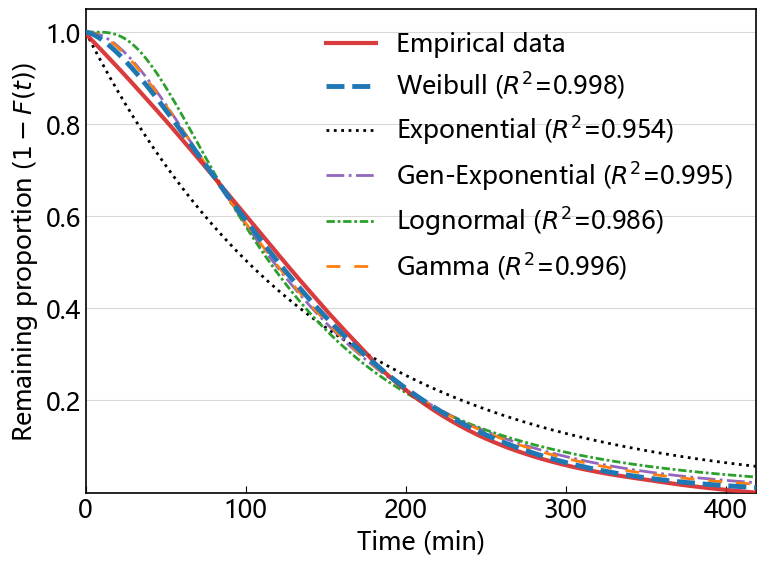

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import norm, gamma
from scipy.optimize import curve_fit


def calculate_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


ts_national = df_night_wb['time_bin'].value_counts()
ts_sorted = ts_national.sort_index().reindex(range(0, int(ts_national.index.max()) + 1), fill_value=0)
S = ts_sorted.cumsum().astype(float)
S_total = S.iloc[-1]

f = S / S_total
one_minus_f = 1 - f

empirical_x = ts_sorted.index.values
empirical_y = one_minus_f.values

print("Fitting theoretical distributions and calculating R2...")

valid_idx = (empirical_x > 0) & (empirical_y > 0) & (empirical_y < 1)
x_fit = empirical_x[valid_idx]
y_fit = empirical_y[valid_idx]

def exp_sf(x, lam):
    return np.exp(-lam * x)

popt_e, _ = curve_fit(exp_sf, x_fit, y_fit, p0=[0.01], bounds=(0, np.inf))
r2_exp = calculate_r2(y_fit, exp_sf(x_fit, *popt_e))


def weibull_sf(x, scale, k):
    return np.exp(- (x / scale)**k)

popt_w, _ = curve_fit(weibull_sf, x_fit, y_fit, p0=[100, 1.5], bounds=([0, 0], [np.inf, np.inf]))
r2_weibull = calculate_r2(y_fit, weibull_sf(x_fit, *popt_w))


def lognorm_sf(x, mu, sigma):
    return 1 - norm.cdf((np.log(x) - mu) / sigma)

popt_l, _ = curve_fit(lognorm_sf, x_fit, y_fit, p0=[np.log(100), 1.0], bounds=([-np.inf, 0], [np.inf, np.inf]))
r2_lognorm = calculate_r2(y_fit, lognorm_sf(x_fit, *popt_l))


def gen_exp_sf(x, lam, alpha):
    return 1 - (1 - np.exp(-lam * x))**alpha

popt_ge, _ = curve_fit(gen_exp_sf, x_fit, y_fit, p0=[0.01, 1.0], bounds=([0, 0], [np.inf, np.inf]))
r2_gen_exp = calculate_r2(y_fit, gen_exp_sf(x_fit, *popt_ge))

def gamma_sf(x, shape, scale):
    return gamma.sf(x, a=shape, scale=scale)

popt_g, _ = curve_fit(gamma_sf, x_fit, y_fit, p0=[2.0, 50.0], bounds=([0, 0], [np.inf, np.inf]))
r2_gamma = calculate_r2(y_fit, gamma_sf(x_fit, *popt_g))


print(f"Exponential R²: {r2_exp:.4f}")
print(f"Weibull R²: {r2_weibull:.4f}")
print(f"Lognormal R²: {r2_lognorm:.4f}")
print(f"Gen-Exponential R²: {r2_gen_exp:.4f}")
print(f"Gamma R²: {r2_gamma:.4f}")


fig, ax = plt.subplots(figsize=(8, 6))


ax.plot(empirical_x, empirical_y, color='#d62728', linewidth=3, alpha=0.9, zorder=6, label='Empirical data')


max_time = empirical_x.max()
x_vals = np.linspace(1e-5, max_time * 1.05, 500)


ax.plot(x_vals, weibull_sf(x_vals, *popt_w), color='#1f77b4', linestyle='--', linewidth=3.5, zorder=7, 
        label=f'Weibull ($R^2$={r2_weibull:.3f})')

ax.plot(x_vals, exp_sf(x_vals, *popt_e), color='black', linestyle=':', linewidth=2, zorder=4, 
        label=f'Exponential ($R^2$={r2_exp:.3f})')

ax.plot(x_vals, gen_exp_sf(x_vals, *popt_ge), color='#9467bd', linestyle='-.', linewidth=2, zorder=4, 
        label=f'Gen-Exponential ($R^2$={r2_gen_exp:.3f})')

ax.plot(x_vals, lognorm_sf(x_vals, *popt_l), color='#2ca02c', linestyle=(0, (3, 1, 1, 1)), linewidth=2, zorder=4, 
        label=f'Lognormal ($R^2$={r2_lognorm:.3f})')

ax.plot(x_vals, gamma_sf(x_vals, *popt_g), color='#ff7f0e', linestyle=(0, (5, 5)), linewidth=2, zorder=4, 
        label=f'Gamma ($R^2$={r2_gamma:.3f})')


ax.set_xlim(0, max_time)
ax.set_ylim(0, 1.05)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0]) 
ax.set_xlabel("Time (min)")
ax.set_ylabel("Remaining proportion ($1 - F(t)$)")
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', length=5, direction='in')
ax.yaxis.grid(True, linestyle='-', color='gray', alpha=0.3)
ax.legend(loc='upper right', frameon=False)

plt.tight_layout()
# plt.savefig(r"../plot/robustness/national_decay.jpg", format='jpg', bbox_inches='tight', dpi=300)
plt.show()

sample size:   10 | mean corr: 0.2837 ± 0.0334
sample size:   50 | mean corr: 0.5972 ± 0.0445
sample size:  100 | mean corr: 0.7409 ± 0.0227
sample size:  200 | mean corr: 0.8340 ± 0.0088
sample size:  300 | mean corr: 0.8812 ± 0.0068
sample size:  500 | mean corr: 0.9235 ± 0.0080
sample size:  800 | mean corr: 0.9513 ± 0.0029
sample size: 1000 | mean corr: 0.9605 ± 0.0027
sample size: 2000 | mean corr: 0.9811 ± 0.0010
sample size: 4000 | mean corr: 0.9915 ± 0.0010


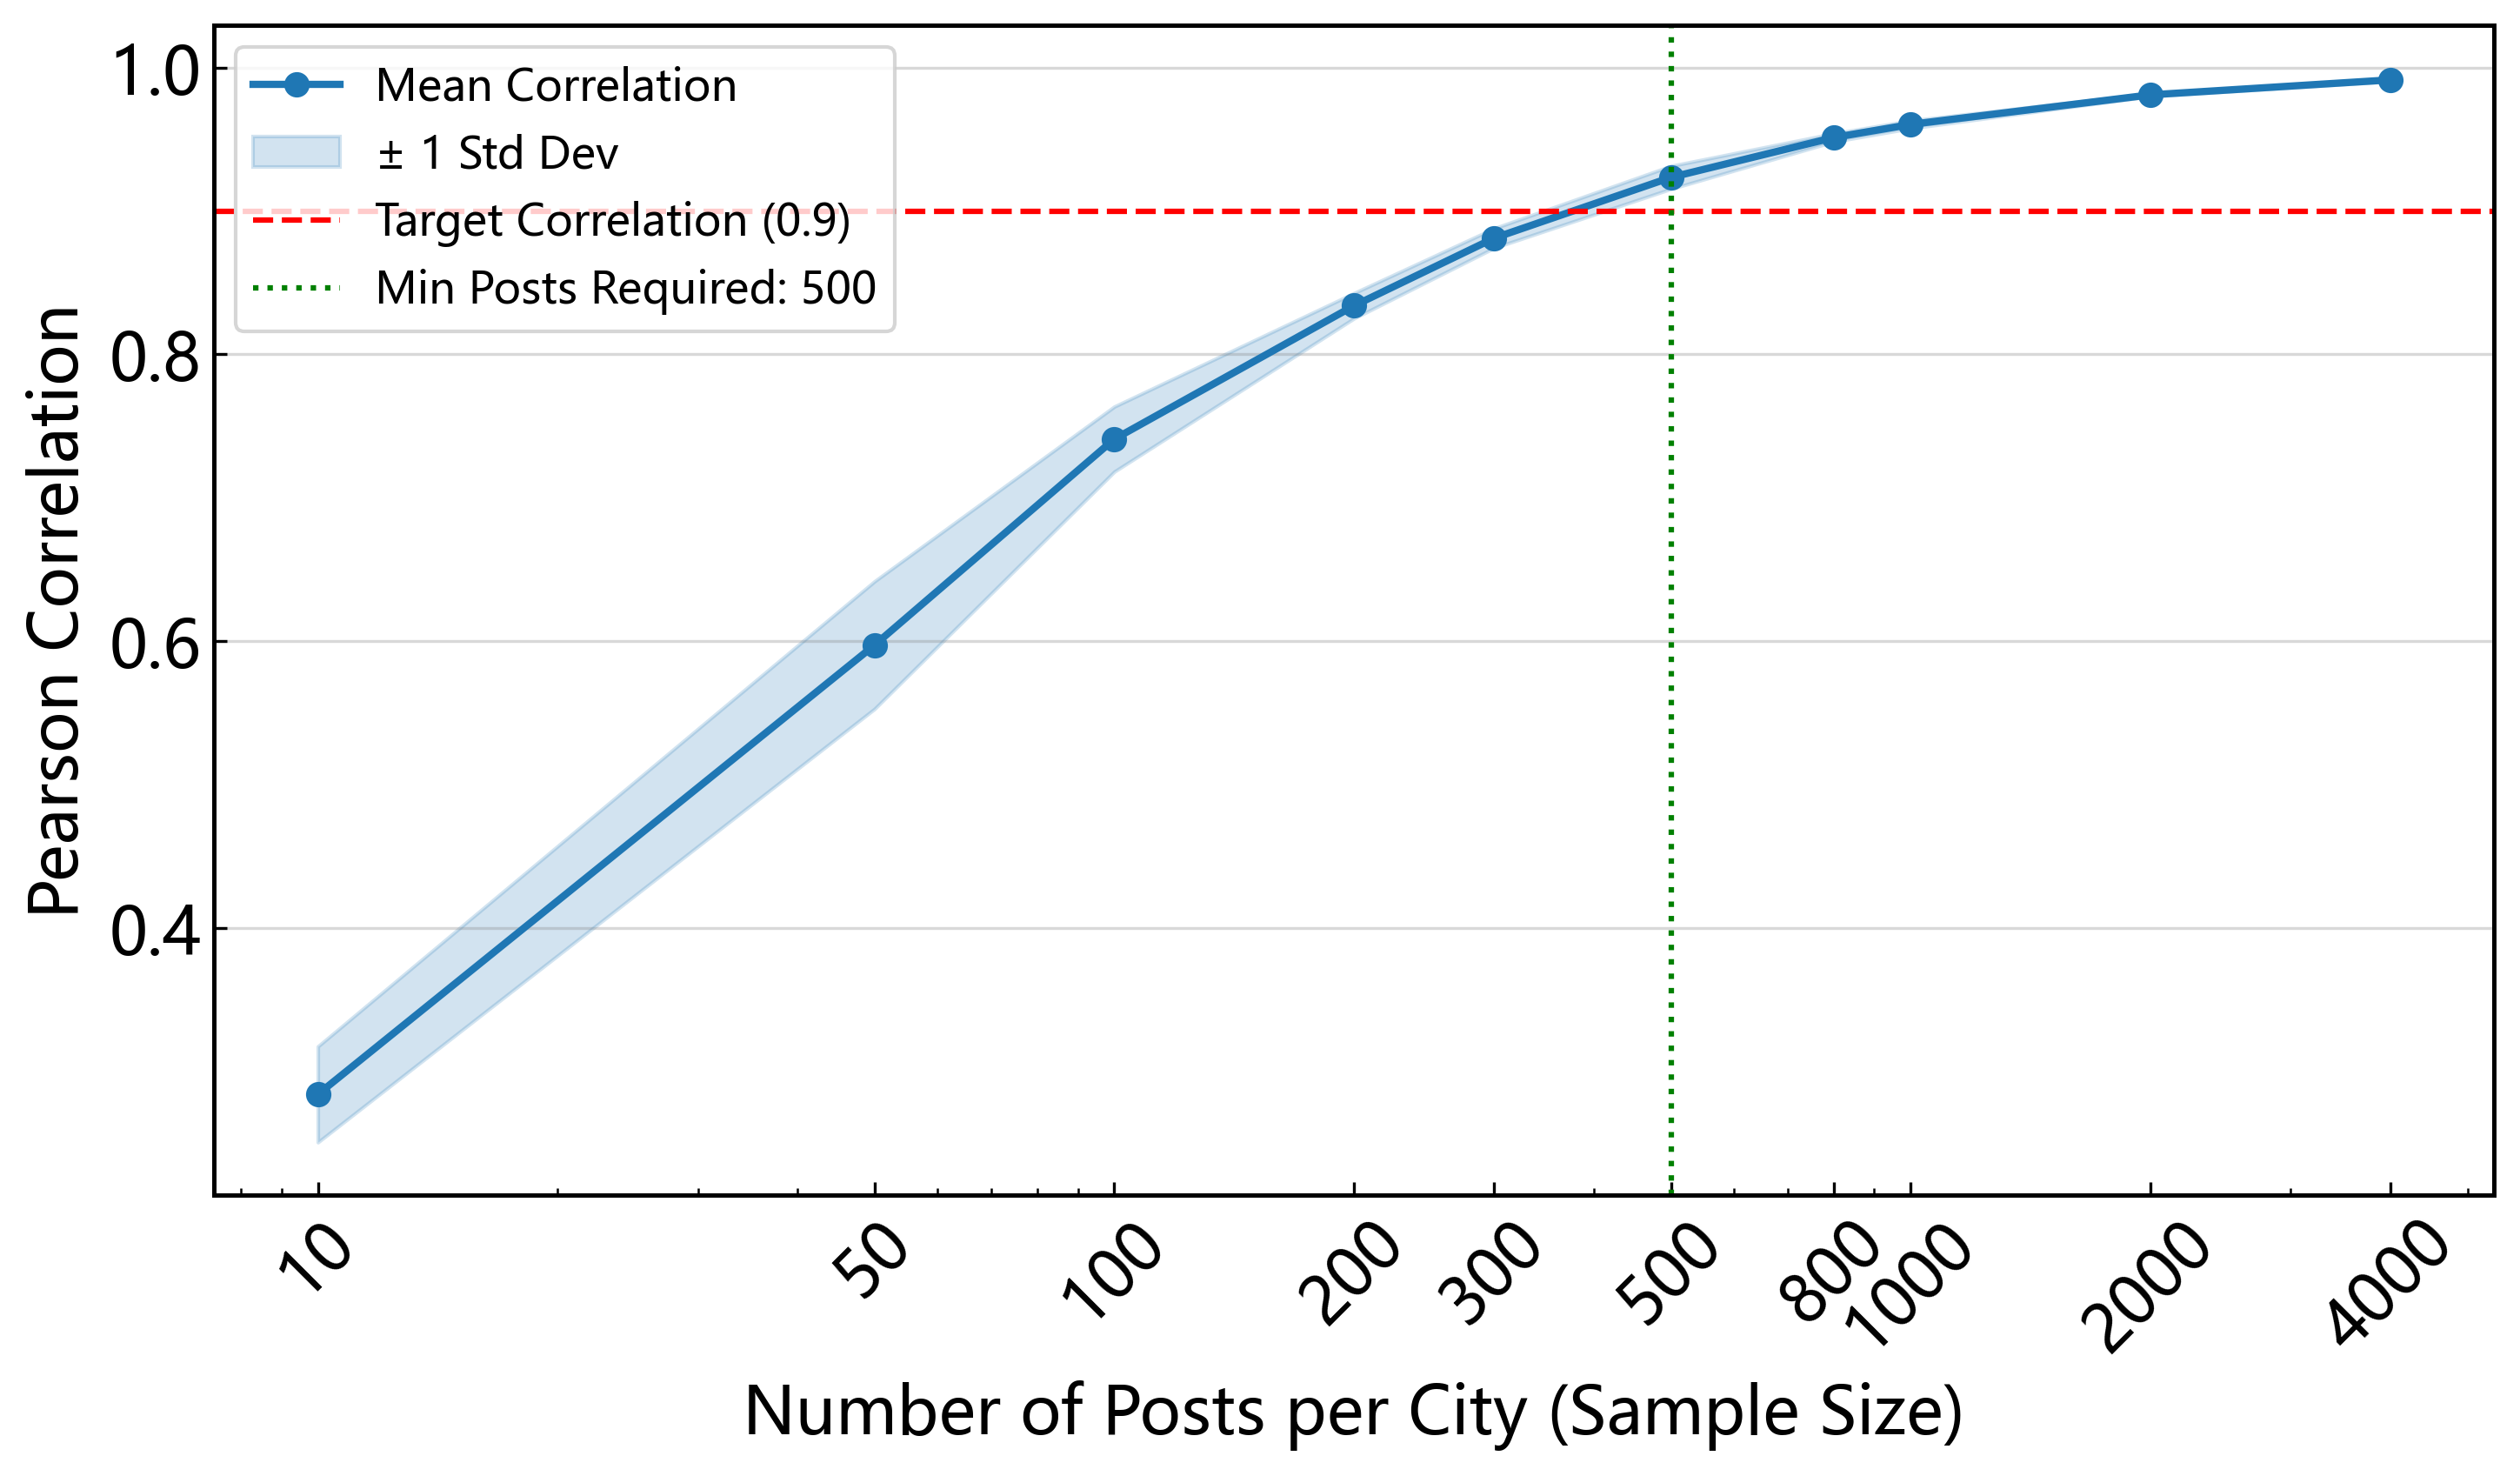

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

def get_npi(group):
    ts = group['time_bin'].value_counts()
    if ts.sum() < 10:  
        return np.nan
    
    ts_sorted = ts.sort_index().reindex(range(0, int(ts.index.max()) + 1), fill_value=0)
    S = ts_sorted.cumsum().astype(float)
    S_total = S.iloc[-1]
    if S_total == 0: 
        return np.nan
    
    f = S / S_total
    one_minus_f = 1 - f
    
    mask_50 = one_minus_f <= 0.5
    if not mask_50.any(): 
        return np.nan
    
    t_50 = mask_50.idxmax()
    if t_50 <= 0: 
        return np.nan
        
    return t_50



full_npi = df_night_wb.groupby('city').apply(get_npi).rename("full_npi").dropna()

sample_sizes = [10, 50, 100, 200, 300, 500, 800, 1000, 2000, 4000]
n_iterations = 10 
results = []

max_sample = 4000
city_counts = df_night_wb['city'].value_counts()
valid_cities = city_counts[city_counts >= max_sample].index
df_test = df_night_wb[df_night_wb['city'].isin(valid_cities)]
full_npi_test = full_npi[full_npi.index.isin(valid_cities)]


for n in sample_sizes:
    corrs = []
    for i in range(n_iterations):
        sampled_df = df_test.groupby('city').sample(n=n)
        
        sample_npi = sampled_df.groupby('city').apply(get_npi).rename("sample_npi").dropna()
        
        merged = pd.concat([full_npi_test, sample_npi], axis=1, join='inner')
        if len(merged) > 5:
            corr, _ = pearsonr(merged['full_npi'], merged['sample_npi'])
            corrs.append(corr)

    if corrs:
        mean_corr = np.mean(corrs)
        std_corr = np.std(corrs)
    else:
        mean_corr = np.nan
        std_corr = np.nan
        
    results.append({
        'sample_size': n, 
        'mean_corr': mean_corr, 
        'std_corr': std_corr
    })
    print(f"sample size: {n:4d} | mean corr: {mean_corr:.4f} ± {std_corr:.4f}")


res_df = pd.DataFrame(results)


target_corr = 0.9
if (res_df['mean_corr'] >= target_corr).any():
    min_n_09 = res_df[res_df['mean_corr'] >= target_corr]['sample_size'].min()


fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

ax.plot(res_df['sample_size'], res_df['mean_corr'], marker='o', linestyle='-', color='#1f77b4', linewidth=2, label='Mean Correlation')

ax.fill_between(res_df['sample_size'], 
                res_df['mean_corr'] - res_df['std_corr'], 
                res_df['mean_corr'] + res_df['std_corr'], 
                color='#1f77b4', alpha=0.2, label='± 1 Std Dev')

ax.axhline(y=target_corr, color='r', linestyle='--', label=f'Target Correlation ({target_corr})')
if pd.notna(min_n_09):
    ax.axvline(x=min_n_09, color='g', linestyle=':', label=f'Min Posts Required: {min_n_09}')

ax.set_xscale('log')
ax.set_xticks(sample_sizes)
ax.set_xticklabels(sample_sizes, rotation=45)
ax.set_xlabel('Number of Posts per City (Sample Size)')
ax.set_ylabel('Pearson Correlation')

ax.yaxis.grid(True, linestyle='-', color='gray', alpha=0.3)
ax.legend(loc='upper left', fontsize=12)
plt.tight_layout()
# plt.savefig(r"../plot/robustness/stresstest.jpg", format='jpg', bbox_inches='tight', dpi=300)
plt.show()

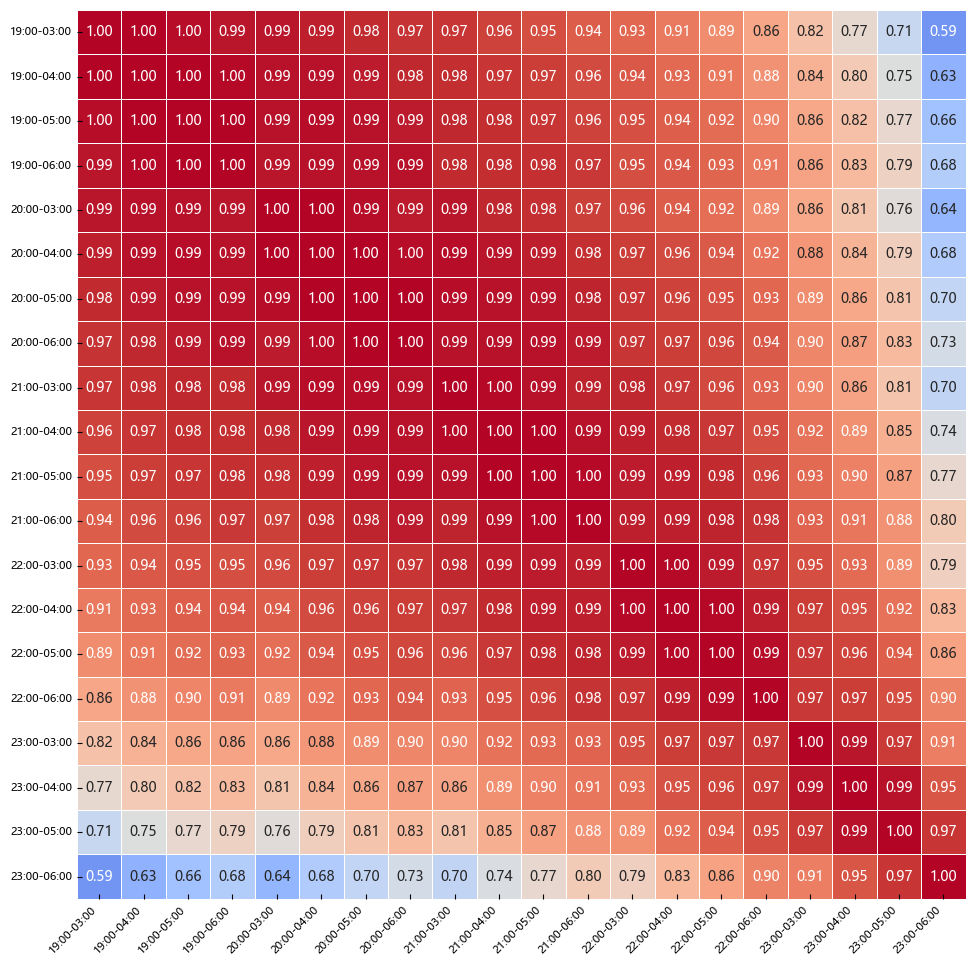

In [9]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False 



def weibull_sf(t, lambda_, k):
    return np.exp(-((np.maximum(t, 0) / lambda_) ** k))

def get_medians(data, sh, eh):
    d = data[['city', 'create_time']].copy()
    if not pd.api.types.is_datetime64_any_dtype(d['create_time']):
        d['create_time'] = pd.to_datetime(d['create_time'])
        
    d['hour'] = d['create_time'].dt.hour
    d['minute'] = d['create_time'].dt.minute

    if sh < eh:
        mask = (d['hour'] >= sh) & (d['hour'] < eh)
        dur = (eh - sh) * 60
    else:
        mask = (d['hour'] >= sh) | (d['hour'] < eh)
        dur = (24 - sh + eh) * 60
        
    d = d[mask].copy()
    d['rel_min'] = np.where(d['hour'] >= sh, d['hour'] - sh, d['hour'] + 24 - sh) * 60 + d['minute']
    counts = pd.crosstab(d['city'], d['rel_min']).reindex(columns=np.arange(dur), fill_value=0)
    
    res = {}
    t = np.arange(dur)
    for city, row in counts.iterrows():
        total = row.sum()

        y_norm = (total - np.insert(np.cumsum(row.values), 0, total)[:-1]) / total
        lam_guess = np.argmin(np.abs(y_norm - np.exp(-1))) or 1.0
        
        try:
            popt, _ = curve_fit(weibull_sf, t, y_norm, p0=[lam_guess, 1.5], bounds=([0.001, 0.001], [np.inf, np.inf]))
            res[city] = popt[0] * (np.log(2) ** (1 / popt[1]))
        except: 
            pass
    return pd.Series(res, name=f'{sh:02d}:00-{eh:02d}:00')

start_hours = [19, 20, 21, 22, 23]
end_hours = [3, 4, 5, 6]

results = []
for sh in start_hours:
    for eh in end_hours:
        results.append(get_medians(df_wb, sh, eh))

comp = pd.concat(results, axis=1)


corr_matrix = comp.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=0.5, vmax=1.0, 
            square=True, linewidths=.5, cbar=False,
            annot_kws={"size": 10})


plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
# plt.savefig(r'../plot/robustness/time_windows.jpg', dpi=300)
plt.tight_layout()
plt.show()